In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

population_df = pd.read_csv("population_increase.csv")

print("人口增減資料：", population_df.shape)

人口增減資料： (44, 24)


In [2]:
population_long = population_df.melt(
    id_vars=population_df.columns[0],
    var_name="縣市",
    value_name="數值"
)

population_long = population_long.rename(
    columns={population_df.columns[0]: "統計項目"}
)

population_long[["期間", "指標"]] = population_long[
    "統計項目"
].str.split("/", n=1, expand=True)

population_long["期間"] = population_long["期間"].str.strip()

population_long["指標"] = population_long["指標"].str.strip()

population_long["縣市"] = (
    population_long["縣市"]
    .str.replace("_統計", "", regex=False)
    .str.strip()
)

population_long["數值"] = pd.to_numeric(
    population_long["數值"],
    errors="coerce"
)

print("整理後資料筆數：", len(population_long))
print("空值數量：", population_long.isna().sum().sum())

population_long.head()

整理後資料筆數： 1012
空值數量： 0


,統計項目,縣市,數值,期間,指標
0,109年 (1~10月)/ 人口數(人),區域別總計,23566471.00,109年 (1~10月),人口數(人)
1,109年 (1~10月)/ 總增加率(o/oo),區域別總計,-1.55,109年 (1~10月),總增加率(o/oo)
2,109年 (1~10月)/ 自然增加率(o/oo),區域別總計,-0.46,109年 (1~10月),自然增加率(o/oo)
3,109年 (1~10月)/ 社會增加率(o/oo),區域別總計,-1.10,109年 (1~10月),社會增加率(o/oo)
4,109年 1月/ 人口數(人),區域別總計,23604265.00,109年 1月,人口數(人)


In [3]:
population_long.to_csv(
    "population_long.csv",
    index=False,
    encoding="utf-8-sig"
)

print("已儲存：population_long.csv")

已儲存：population_long.csv


In [4]:
age_df = pd.read_csv("population_age_groups.csv")

print("年齡結構資料：", age_df.shape)

age_df.head()

年齡結構資料： (299, 5)


,人口數,人口數.1,幼年人口_0至14歲_統計,工作年齡人口_15至64歲_統計,老年人口_65歲以上_統計
0,106年/ 區域別總計 / 計,"23,571,227","3,091,873","17,211,341","3,268,013"
1,106年/ 新北市 / 計,"3,986,689","498,155","2,986,137","502,397"
2,106年/ 臺北市 / 計,"2,683,257","369,872","1,874,209","439,176"
3,106年/ 桃園市 / 計,"2,188,017","331,649","1,620,364","236,004"
4,106年/ 臺中市 / 計,"2,787,070","407,467","2,059,022","320,581"


In [5]:
age_annual = age_df[
    age_df.iloc[:, 0]
    .astype(str)
    .str.startswith("106年/")
].copy()

print("年度資料：", age_annual.shape)

age_annual.head()

年度資料： (23, 5)


,人口數,人口數.1,幼年人口_0至14歲_統計,工作年齡人口_15至64歲_統計,老年人口_65歲以上_統計
0,106年/ 區域別總計 / 計,"23,571,227","3,091,873","17,211,341","3,268,013"
1,106年/ 新北市 / 計,"3,986,689","498,155","2,986,137","502,397"
2,106年/ 臺北市 / 計,"2,683,257","369,872","1,874,209","439,176"
3,106年/ 桃園市 / 計,"2,188,017","331,649","1,620,364","236,004"
4,106年/ 臺中市 / 計,"2,787,070","407,467","2,059,022","320,581"


In [6]:
age_annual = age_annual.rename(columns={
    age_annual.columns[0]: "統計項目",
    age_annual.columns[1]: "總人口數",
    age_annual.columns[2]: "幼年人口_0_14歲",
    age_annual.columns[3]: "工作年齡人口_15_64歲",
    age_annual.columns[4]: "老年人口_65歲以上"
})

age_annual["縣市"] = (
    age_annual["統計項目"]
    .str.extract(r"106年/([^/]+)/", expand=False)
    .str.strip()
)

age_annual[["統計項目", "縣市"]].head()

,統計項目,縣市
0,106年/ 區域別總計 / 計,區域別總計
1,106年/ 新北市 / 計,新北市
2,106年/ 臺北市 / 計,臺北市
3,106年/ 桃園市 / 計,桃園市
4,106年/ 臺中市 / 計,臺中市


In [7]:
numeric_cols = [
    "總人口數",
    "幼年人口_0_14歲",
    "工作年齡人口_15_64歲",
    "老年人口_65歲以上"
]

for col in numeric_cols:
    age_annual[col] = pd.to_numeric(
        age_annual[col]
        .astype(str)
        .str.replace(",", "", regex=False),
        errors="coerce"
    )

print(age_annual[numeric_cols].dtypes)
age_annual.head()

總人口數             int64
幼年人口_0_14歲       int64
工作年齡人口_15_64歲    int64
老年人口_65歲以上       int64
dtype: object


,統計項目,總人口數,幼年人口_0_14歲,工作年齡人口_15_64歲,老年人口_65歲以上,縣市
0,106年/ 區域別總計 / 計,23571227,3091873,17211341,3268013,區域別總計
1,106年/ 新北市 / 計,3986689,498155,2986137,502397,新北市
2,106年/ 臺北市 / 計,2683257,369872,1874209,439176,臺北市
3,106年/ 桃園市 / 計,2188017,331649,1620364,236004,桃園市
4,106年/ 臺中市 / 計,2787070,407467,2059022,320581,臺中市


In [8]:
age_annual["幼年比例(%)"] = (
    age_annual["幼年人口_0_14歲"]
    / age_annual["總人口數"]
    * 100
)

age_annual["工作年齡比例(%)"] = (
    age_annual["工作年齡人口_15_64歲"]
    / age_annual["總人口數"]
    * 100
)

age_annual["老年比例(%)"] = (
    age_annual["老年人口_65歲以上"]
    / age_annual["總人口數"]
    * 100
)

age_annual[
    [
        "縣市",
        "幼年比例(%)",
        "工作年齡比例(%)",
        "老年比例(%)"
    ]
].head()

,縣市,幼年比例(%),工作年齡比例(%),老年比例(%)
0,區域別總計,13.117149,73.018435,13.864416
1,新北市,12.495457,74.902682,12.601861
2,臺北市,13.784442,69.848285,16.367273
3,桃園市,15.157515,74.056280,10.786205
4,臺中市,14.619905,73.877656,11.502438


In [9]:
age_annual.to_csv(
    "age_annual.csv",
    index=False,
    encoding="utf-8-sig"
)

print("已儲存：age_annual.csv")

已儲存：age_annual.csv


In [10]:
national_age = age_annual[
    age_annual["縣市"] == "區域別總計"
].copy()

national_age[
    [
        "縣市",
        "幼年比例(%)",
        "工作年齡比例(%)",
        "老年比例(%)"
    ]
]

,縣市,幼年比例(%),工作年齡比例(%),老年比例(%)
0,區域別總計,13.117149,73.018435,13.864416


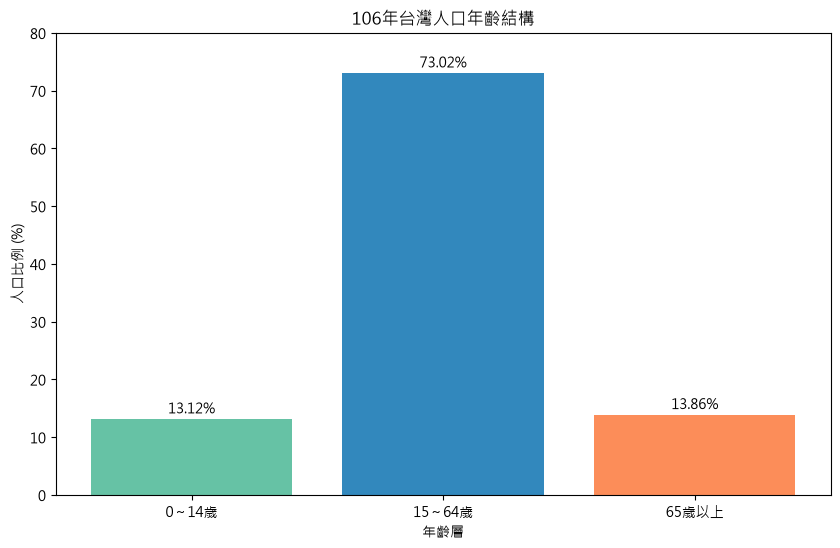

In [11]:
age_labels = [
    "0～14歲",
    "15～64歲",
    "65歲以上"
]

age_values = [
    national_age["幼年比例(%)"].iloc[0],
    national_age["工作年齡比例(%)"].iloc[0],
    national_age["老年比例(%)"].iloc[0]
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    age_labels,
    age_values,
    color=["#66c2a5", "#3288bd", "#fc8d59"]
)

plt.title("106年台灣人口年齡結構")
plt.xlabel("年齡層")
plt.ylabel("人口比例 (%)")
plt.ylim(0, 80)

for bar, value in zip(bars, age_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

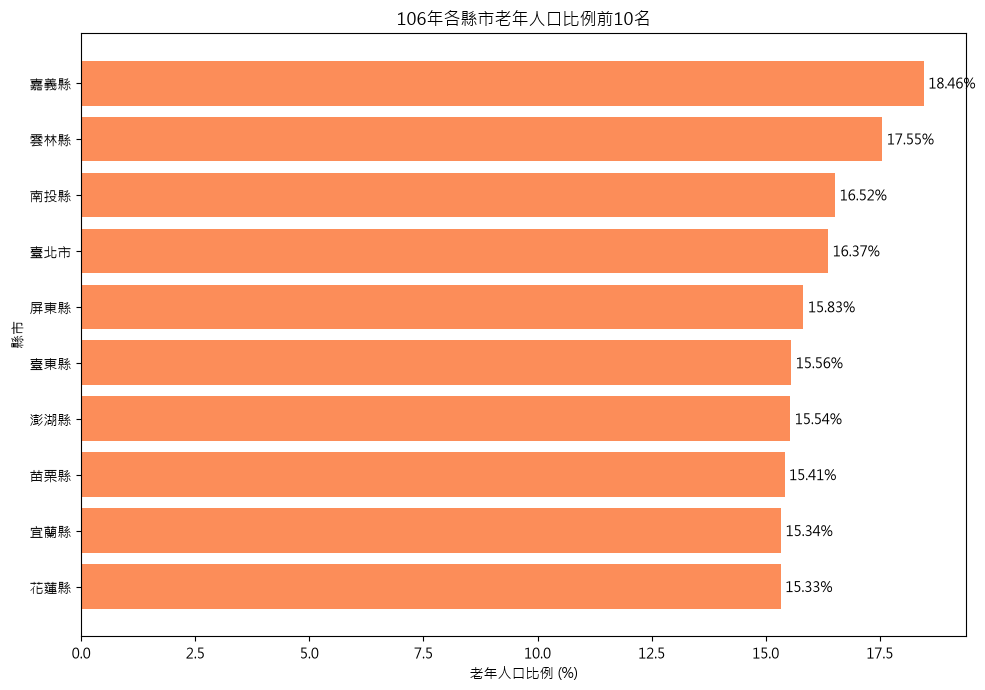

In [12]:
elderly_top10 = (
    age_annual[
        age_annual["縣市"] != "區域別總計"
    ]
    .nlargest(10, "老年比例(%)")
    .sort_values("老年比例(%)")
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    elderly_top10["縣市"],
    elderly_top10["老年比例(%)"],
    color="#fc8d59"
)

plt.title("106年各縣市老年人口比例前10名")
plt.xlabel("老年人口比例 (%)")
plt.ylabel("縣市")

for bar, value in zip(
    bars,
    elderly_top10["老年比例(%)"]
):
    plt.text(
        value + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

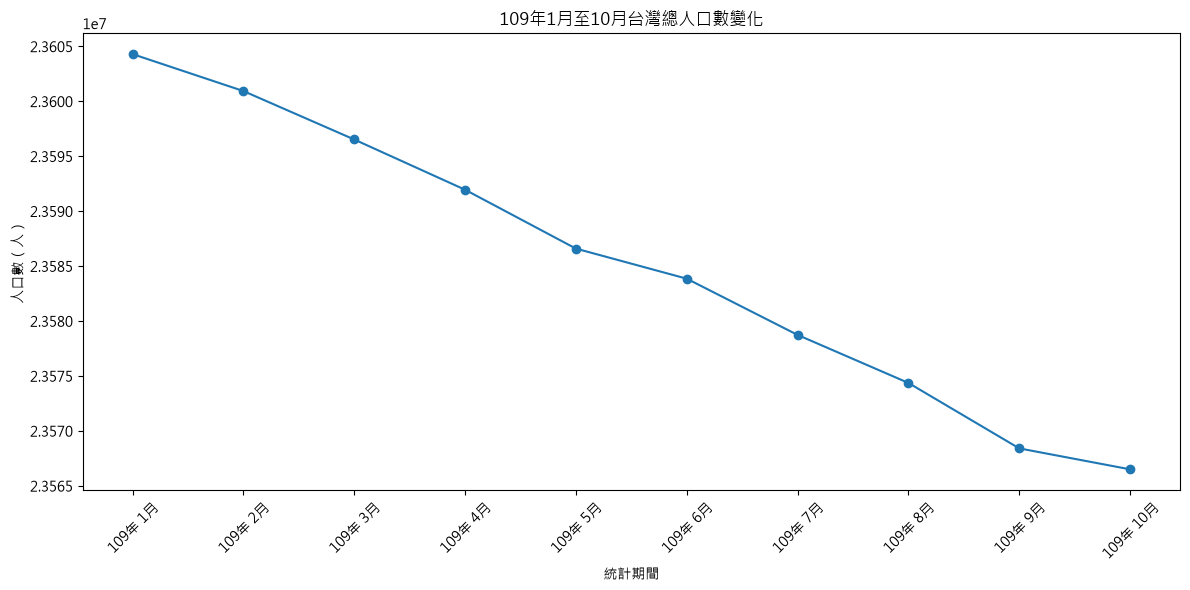

In [13]:
population_monthly = population_long[
    (population_long["縣市"] == "區域別總計")
    & (population_long["指標"] == "人口數(人)")
    & (population_long["期間"].str.match(r"109年 \d+月"))
].copy()

population_monthly["月份"] = (
    population_monthly["期間"]
    .str.extract(r"(\d+)月")
    .astype(int)
)

population_monthly = population_monthly.sort_values("月份")

plt.figure(figsize=(12, 6))

plt.plot(
    population_monthly["期間"],
    population_monthly["數值"],
    marker="o"
)

plt.title("109年1月至10月台灣總人口數變化")
plt.xlabel("統計期間")
plt.ylabel("人口數（人）")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

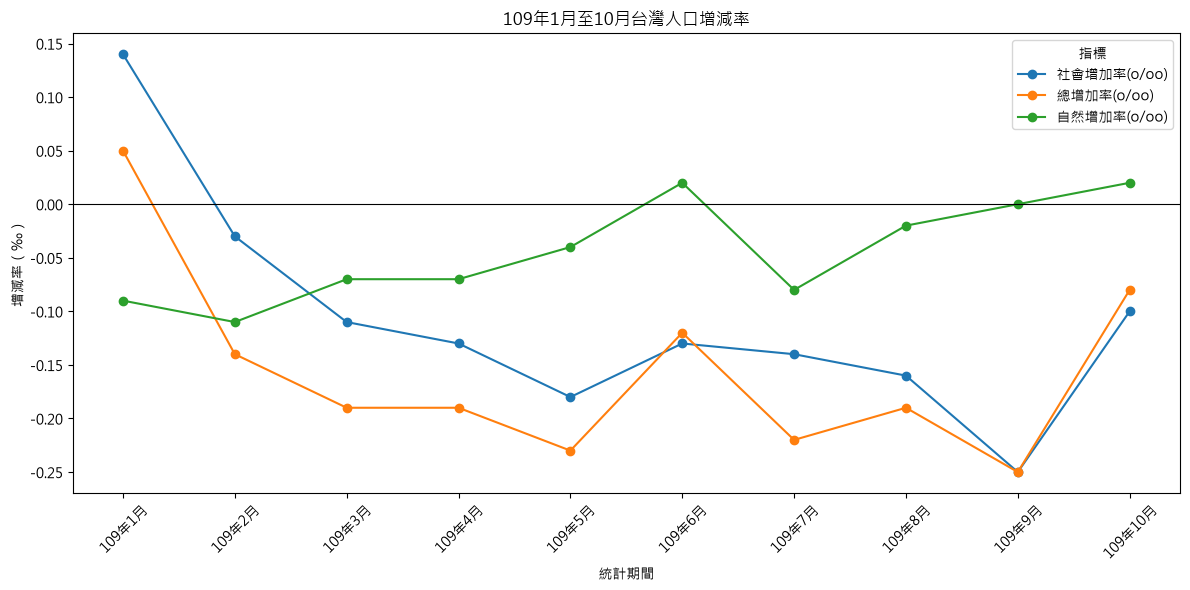

In [14]:
growth_indicators = [
    "社會增加率(o/oo)",
    "總增加率(o/oo)",
    "自然增加率(o/oo)"
]

growth_monthly = population_long[
    (population_long["縣市"] == "區域別總計")
    & (population_long["指標"].isin(growth_indicators))
    & (population_long["期間"].str.match(r"109年 \d+月"))
].copy()

growth_monthly["月份"] = (
    growth_monthly["期間"]
    .str.extract(r"(\d+)月")
    .astype(int)
)

growth_pivot = (
    growth_monthly
    .pivot(
        index="月份",
        columns="指標",
        values="數值"
    )
    .sort_index()
)

period_labels = [
    f"109年{month}月"
    for month in growth_pivot.index
]

plt.figure(figsize=(12, 6))

for indicator in growth_indicators:
    plt.plot(
        growth_pivot.index,
        growth_pivot[indicator],
        marker="o",
        label=indicator
    )

plt.axhline(0, color="black", linewidth=0.8)

plt.title("109年1月至10月台灣人口增減率")
plt.xlabel("統計期間")
plt.ylabel("增減率（‰）")
plt.xticks(growth_pivot.index, period_labels, rotation=45)
plt.legend(title="指標")

plt.tight_layout()
plt.show()

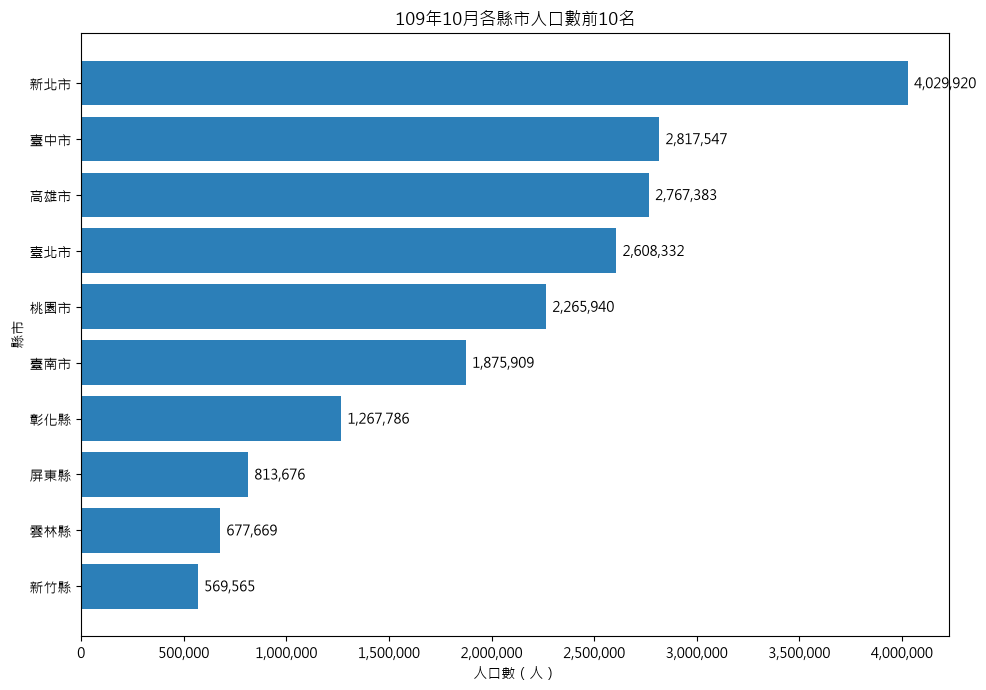

In [15]:
from matplotlib.ticker import FuncFormatter

population_oct = population_long[
    (population_long["縣市"] != "區域別總計")
    & (population_long["期間"] == "109年 10月")
    & (population_long["指標"] == "人口數(人)")
].copy()

top10_population = (
    population_oct
    .nlargest(10, "數值")
    .sort_values("數值")
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top10_population["縣市"],
    top10_population["數值"],
    color="#2c7fb8"
)

plt.title("109年10月各縣市人口數前10名")
plt.xlabel("人口數（人）")
plt.ylabel("縣市")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, position: f"{int(x):,}")
)

for bar, value in zip(
    bars,
    top10_population["數值"]
):
    plt.text(
        value + 30000,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

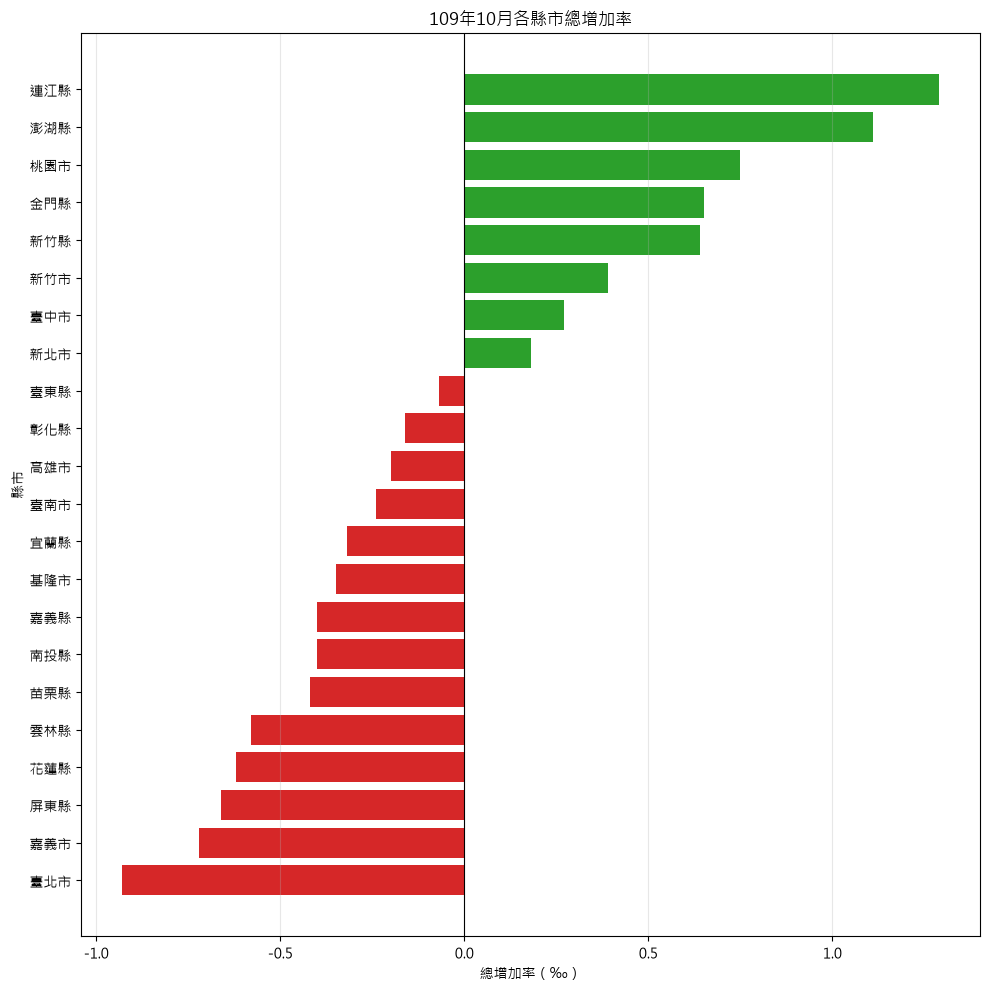

In [16]:
growth_oct = population_long[
    (population_long["縣市"] != "區域別總計")
    & (population_long["期間"] == "109年 10月")
    & (population_long["指標"] == "總增加率(o/oo)")
].copy()

growth_oct = growth_oct.sort_values("數值")

colors = [
    "#2ca02c" if value >= 0 else "#d62728"
    for value in growth_oct["數值"]
]

plt.figure(figsize=(10, 10))

plt.barh(
    growth_oct["縣市"],
    growth_oct["數值"],
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)

plt.title("109年10月各縣市總增加率")
plt.xlabel("總增加率（‰）")
plt.ylabel("縣市")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# 03｜政府人口資料分析

## 分析目的

使用政府公開人口資料，分析台灣人口數變化、各縣市人口規模、人口增減率，以及不同年齡層的人口結構。

## 資料來源

- [人口增減─按區域別分](https://data.gov.tw/dataset/14223)
- [人口數三段年齡組─按區域別分](https://data.gov.tw/dataset/14224)

## 分析工具

Python、Pandas、Matplotlib

## 主要分析結果

1. 109 年 1 月至 10 月，台灣總人口數由 23,604,265 人下降至 23,566,471 人，共減少 37,794 人。
2. 109 年 10 月人口數最多的縣市為新北市，其次為臺中市、高雄市、臺北市與桃園市。
3. 109 年 10 月各縣市總增加率差異明顯，部分縣市人口正成長，部分縣市則呈現負成長。
4. 106 年台灣人口結構中，0～14 歲人口占 13.12%，15～64 歲占 73.02%，65 歲以上占 13.86%。
5. 106 年老年人口比例最高的縣市為嘉義縣，其次為雲林縣與南投縣。

## 資料限制

人口增減資料為 109 年 1 月至 10 月資料，年齡結構資料則為 106 年資料，兩份資料年份不同，因此本分析主要進行個別資料集的結構與趨勢分析，未直接比較兩個年份的變化。